# <font color="steelblue">Ponderación de modelos: Bagging inicial</font>

**Material desarrollado por los [equipos de trabajo de IA4LEGOS](https://ia4legos.umh.es/)**

**Fecha última edición**: 08/06/2026

**Licencia**: <a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a>

No olvides hacer una copia si deseas utilizarlo.

In [1]:
# @title Cargar configuración del cuaderno
!pip install gdown
!pip install --upgrade kagglehub
!pip install lightgbm xgboost
!pip install mlxtend --upgrade --no-deps
!pip install pingouin --upgrade
!pip install imbalanced-learn --upgrade
!pip install graphviz

# Análisis numérico
import numpy as np
import pandas as pd
import math, random
import warnings
warnings.filterwarnings('ignore')

# Gráficos
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.patches import Ellipse
import seaborn as sns
sns.set_theme(style='whitegrid')
%config InlineBackend.figure_format = 'retina'

import os, zipfile, gdown, kagglehub

# Funciones de preprocesado, evaluación, CP y auto_ML
from urllib.request import urlretrieve
for fichero in ['preprocesar.py', 'evaluar_clasificadores.py', 'pca_funciones.py', 'auto_ML.py']:
    urlretrieve(f'https://raw.githubusercontent.com/ia4legos/MachineLearning/refs/heads/main/{fichero}', fichero)
from preprocesar import *
from evaluar_clasificadores import *
from pca_funciones import *
from auto_ML import *

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, learning_curve, GridSearchCV, KFold
from sklearn.feature_selection import RFE, f_classif
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             roc_curve, roc_auc_score, make_scorer, f1_score, recall_score)
from sklearn.utils import resample
from mlxtend.plotting import plot_decision_regions
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
import pingouin
from sklearn.metrics import pairwise_distances

RNG = 42

# Modelos base e instrumentos de bagging
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier, BaggingClassifier
from sklearn.datasets import load_wine

RNG = 42

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.3 MB/s eta 0:00:00
  Attempting uninstall: mlxtend
    Found existing installation: mlxtend 0.23.4
    Uninstalling mlxtend-0.23.4:
      Successfully uninstalled mlxtend-0.23.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 8.8 MB/s eta 0:00:00


# <font color="steelblue">Introducción</font>

Si preguntas a **un solo experto**, su respuesta puede estar sesgada por sus manías; si preguntas a **un comité variado** y te quedas con la respuesta mayoritaria, los errores individuales tienden a **cancelarse** y la decisión conjunta suele ser más fiable. Esa es la idea de los **métodos de conjunto** (*ensemble*): combinar varios modelos para obtener uno mejor que cada uno por separado.

En este cuaderno tratamos la familia **bagging** (*bootstrap aggregating*). Cerramos así el bloque de algoritmos individuales de clasificación (logística, discriminante, Naïve Bayes, *k*-NN, SVM, árboles) y damos el salto a **combinarlos**. A diferencia de cuadernos anteriores, trabajaremos **directamente con datos reales** —potabilidad del agua, cáncer de mama, abulones y vinos—, usando los modelos con sus **hiperparámetros por defecto** y apoyándonos en las funciones de comparación del curso.

# <font color="steelblue">1. ¿Qué es el bagging?</font>

El término **bagging** es la contracción de **b**ootstrap **agg**regat**ing**, y resume sus dos ingredientes:

* **Bootstrap:** a partir de la muestra de entrenamiento se generan **muchos subconjuntos** tomando muestras **con reemplazamiento**. Cada subconjunto entrena un modelo, de modo que cada uno "ve" una versión ligeramente distinta de los datos.
* **Aggregating:** las predicciones de todos los modelos se **agregan**: por **votación mayoritaria** en clasificación (la **clase modal**, la más repetida) o **promediando** en regresión.



## <font color="steelblue">1.1. ¿Por qué funciona? Reducción de la varianza</font>

La clave es **reducir la varianza** de los modelos individuales sin aumentar su sesgo. Del **Teorema Central del Límite** sabemos que, al promediar $n$ valores independientes con varianza $\sigma^2$, la varianza del promedio se reduce a

$$\operatorname{Var}(\bar X) = \frac{\sigma^2}{n}.$$

Aplicado a modelos: si entrenamos muchos modelos con **alta varianza** (que cambian mucho según los datos —el ejemplo típico son los **árboles** sin podar—) y promediamos sus salidas, el conjunto **conserva el bajo sesgo** de cada árbol pero con **mucha menos varianza**. Por eso el bagging es especialmente eficaz con modelos **inestables**; en modelos ya estables (logística, discriminante) la mejora es menor.

> En clasificación, la predicción del conjunto es la **clase modal** (votación mayoritaria) o la de **mayor probabilidad promedio** (lo veremos en el voto *soft*).

Los dos algoritmos de bagging más habituales en scikit-learn son el **voto por mayoría** (`VotingClassifier`) y el **ensamble bootstrap genérico** (`BaggingClassifier`).

# <font color="steelblue">2. Voto por mayoría: `VotingClassifier`</font>

El **voto por mayoría** combina varios modelos base **distintos** entrenados sobre la misma muestra. Tiene dos variantes:

* **Voto duro (*hard*):** cada modelo emite su clase predicha y el conjunto se queda con la **clase más votada** (la moda).
* **Voto blando (*soft*):** se **promedian las probabilidades** de clasificación de todos los modelos y se elige la clase con mayor probabilidad promedio.

Para el voto blando, si ajustamos $L$ modelos y hay $K$ clases, cada modelo aporta, para un registro, sus probabilidades $p_{lk}$. Organizadas en una matriz $L\times K$, **promediamos por columnas** para obtener la probabilidad media de cada clase, $\hat p_k$, y clasificamos en la de mayor promedio:

$$\hat y = \arg\max_k\;\hat p_k,\qquad \hat p_k=\frac{1}{L}\sum_{l=1}^{L} p_{lk}.$$

El voto blando suele rendir **algo mejor** que el duro porque aprovecha la **confianza** (probabilidad) de cada modelo, no solo su decisión final. Lo ilustramos con números para **un registro**, tres modelos y dos clases:

In [2]:
# Probabilidades de 3 modelos para un registro (filas = modelos, columnas = clases 0 y 1)
P = np.array([[0.80, 0.20],   # modelo 1 -> vota clase 0
              [0.55, 0.45],   # modelo 2 -> vota clase 0 (por poco)
              [0.20, 0.80]])  # modelo 3 -> vota clase 1
voto_duro = np.bincount(P.argmax(axis=1)).argmax()
prom = P.mean(axis=0)
print('Voto DURO  -> clases votadas:', P.argmax(axis=1), '-> modal:', voto_duro)
print('Voto BLANDO-> probabilidad media por clase:', prom.round(3), '-> clase', prom.argmax())

Voto DURO  -> clases votadas: [0 0 1] -> modal: 0
Voto BLANDO-> probabilidad media por clase: [0.517 0.483] -> clase 0


En *hard* ganan los dos votos a la clase 0. En *soft*, el modelo 3 estaba **muy seguro** (0.80) de la clase 1, lo que arrastra el promedio: aquí coincide en clase 0, pero cuando un modelo muy confiado se opone a otros dudosos, el voto blando puede **cambiar** la decisión. En scikit-learn:

```python
from sklearn.ensemble import VotingClassifier
ensemble = VotingClassifier(estimators=[('lr', clf1), ('rbf', clf2), ('gnb', clf3)], voting='soft')
ensemble.fit(X_train, y_train)
```

donde `estimators` es la lista de modelos base (tuplas nombre–modelo) y `voting` es `'hard'` o `'soft'` (para `'soft'`, todos los modelos deben proporcionar `predict_proba`).


# <font color="steelblue">3. Ensamble bootstrap genérico: `BaggingClassifier`</font>

Mientras el voto por mayoría combina modelos **distintos** sobre los **mismos** datos, `BaggingClassifier` repite **un mismo modelo base** sobre **muchos subconjuntos** de los datos generados por remuestreo, y agrega por votación. Según cómo se construyan esos subconjuntos, el método recibe distintos nombres:

| Variante | Muestrea **observaciones** | Muestrea **variables** |
|---|---|---|
| **Bagging** | sí, con reemplazamiento | no |
| **Pasting** | sí, sin reemplazamiento | no |
| **Subespacios aleatorios** | no | sí |
| **Random Patches** | sí | sí |

**Parámetros principales** de `BaggingClassifier`:

* **`estimator`** — modelo base a replicar (por defecto `DecisionTreeClassifier`).
* **`n_estimators`** — número de modelos del ensamble (por defecto 10).
* **`max_samples`** — nº (o fracción) de observaciones para entrenar cada modelo base.
* **`max_features`** — nº (o fracción) de variables para entrenar cada modelo base.
* **`bootstrap`** — `True` (por defecto) muestrea observaciones **con** reemplazamiento; `False` da *pasting*.
* **`oob_score`** — si `True`, estima el error de generalización con las muestras **fuera de la bolsa** (*out-of-bag*).

```python
from sklearn.ensemble import BaggingClassifier
bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=0)
```

> **Random Forest** y **Extra Trees** son casos célebres de bagging **sobre árboles** que decorrelacionan los árboles eligiendo además variables al azar. Los dejamos para **más adelante**; aquí nos centramos en `VotingClassifier` y en el `BaggingClassifier` genérico.




# <font color="steelblue">4. Modelos base y funciones de comparación</font>

Consideraremos como **modelos base** (con **hiperparámetros por defecto**): regresión **logística**, análisis **discriminante** (LDA), **Naïve Bayes** gaussiano, **k-NN**, **SVM lineal**, **SVM no lineal** (núcleo RBF) y **árbol de decisión**. Frente a ellos compararemos el `BaggingClassifier` genérico.

El curso proporciona dos funciones que **entrenan y comparan** muchos clasificadores sobre una partición interna de validación:

* **`comparar_clasificador_2cls(strain, target, sizeval=0.3, semilla=42, models_to_train=None, pos_label=None)`** — problemas **binarios**. Devuelve *Accuracy, Balanced_Accuracy, Precision, Recall, Specificity, F1* y *AUC* por modelo.
* **`comparar_clasificador_multicls(strain, target, sizeval=0.3, semilla=42, models_to_train=None)`** — **multiclase**. Devuelve *Accuracy, Balanced_Accuracy, Precision, Recall, F1* y *AUC* (estas con `average='weighted'`, AUC *One-vs-Rest*).

Ambas reciben el conjunto **ya preprocesado**, hacen **internamente** la partición entrenamiento/validación y entrenan los modelos de `models_to_train`. Las claves disponibles incluyen los **base** (`lr`, `lda`, `qda`, `nb`, `knn`, `svc`=SVM lineal, `rbf`=SVM RBF, `dt`) y el **ensamble** `bagging` (entre otros que veremos más adelante). **Ordenaremos siempre las tablas por F1.**

In [3]:
modelos_base = ['lr', 'lda', 'nb', 'knn', 'svc', 'rbf', 'dt']
modelos_bag  = ['bagging']            # RF y Extra Trees se verán más adelante
nombres = {'lr': 'Logística', 'lda': 'Discriminante', 'nb': 'Naïve Bayes', 'knn': 'k-NN',
           'svc': 'SVM lineal', 'rbf': 'SVM RBF', 'dt': 'Árbol', 'bagging': 'Bagging'}

def tabla_comparacion(datos, target, multiclase):
    f = comparar_clasificador_multicls if multiclase else comparar_clasificador_2cls
    t = f(datos, target, models_to_train=modelos_base + modelos_bag)
    cols = ['Accuracy', 'Balanced_Accuracy', 'Recall', 'F1', 'AUC']
    if not multiclase:
        cols.insert(3, 'Specificity') # Add Specificity for binary problems
    return t.rename(index=nombres)[cols].sort_values('F1', ascending=False).round(3)

## <font color="steelblue">4.1. Combinación de modelos: ¿con cuántos nos quedamos?</font>

El voto por mayoría puede combinar **todos** los modelos base, pero **más modelos no es siempre mejor**: añadir clasificadores **flojos** puede arrastrar el resultado a la baja. Buscamos por tanto el conjunto **más parsimonioso** —el menor número de modelos que mantiene la F1 estable—, aplicando la navaja de Occam.

El procedimiento es: ordenar los modelos de **mayor a menor F1 ponderada** individual e ir **añadiéndolos uno a uno** al comité, midiendo la F1 ponderada del voto **duro** y **blando** en cada paso. Representamos esa F1 frente al número de modelos y nos quedamos con el **codo**: el menor número de modelos tras el cual la F1 ya no mejora de forma apreciable.

> **Ponderación y desequilibrio.** Usamos como métrica la **F1 ponderada** (`average='weighted'`), adecuada cuando las clases están **desequilibradas**. Además, en los casos desequilibrados activamos `class_weight='balanced'` en los modelos que lo admiten (logística, SVM, árbol), una de las **técnicas de ponderación** vistas para que los modelos no se decanten por la clase mayoritaria.

In [4]:
def estimadores_base(balanceado=False):
    # class_weight='balanced' donde el modelo lo admite (k-NN, NB y LDA no lo tienen)
    cw = 'balanced' if balanceado else None
    return [('Logística',     LogisticRegression(max_iter=1000, random_state=RNG, class_weight=cw)),
            ('Discriminante',  LinearDiscriminantAnalysis()),
            ('Naïve Bayes',    GaussianNB()),
            ('k-NN',           KNeighborsClassifier()),
            ('SVM lineal',     SVC(kernel='linear', probability=True, random_state=RNG, class_weight=cw)),
            ('SVM RBF',        SVC(kernel='rbf', probability=True, random_state=RNG, class_weight=cw)),
            ('Árbol',          DecisionTreeClassifier(random_state=RNG, class_weight=cw))]

def voting_parsimonia(datos, target, balanceado=False, sizeval=0.3, semilla=RNG, tol=0.005, titulo=''):
    # Misma partición que las funciones del curso
    tr, va = split_sample(datos, target, sizeval, semilla, True)
    Xtr, ytr = tr.drop(columns=target), tr[target]
    Xva, yva = va.drop(columns=target), va[target]
    clases = np.array(sorted(pd.unique(ytr), key=str))

    # Ajustamos cada modelo UNA vez y guardamos predicciones y probabilidades
    preds, probas, f1ind = {}, {}, {}
    for nombre, mod in estimadores_base(balanceado):
        m = clone(mod).fit(Xtr, ytr)
        preds[nombre] = m.predict(Xva)
        cols = {c: i for i, c in enumerate(m.classes_)}
        probas[nombre] = m.predict_proba(Xva)[:, [cols[c] for c in clases]]
        f1ind[nombre] = f1_score(yva, preds[nombre], average='weighted')
    orden = sorted(f1ind, key=f1ind.get, reverse=True)   # de mayor a menor F1

    # F1 del voto duro y blando al ir añadiendo modelos top-k
    f1_hard, f1_soft = [], []
    for k in range(1, len(orden) + 1):
        sel = orden[:k]
        M = np.array([preds[n] for n in sel])
        dura = []
        for j in range(M.shape[1]):
            v, c = np.unique(M[:, j], return_counts=True)
            g = v[c == c.max()]
            dura.append(g[0] if len(g) == 1 else M[0, j])   # empate -> mejor modelo
        f1_hard.append(f1_score(yva, np.array(dura), average='weighted'))
        S = np.mean([probas[n] for n in sel], axis=0)
        f1_soft.append(f1_score(yva, clases[S.argmax(axis=1)], average='weighted'))

    ks = list(range(1, len(orden) + 1))
    mejor = max(f1_soft)
    kstar = next(k for k, f in zip(ks, f1_soft) if f >= mejor - tol)   # parsimonioso (sobre soft)

    # Gráfico
    plt.figure(figsize=(8, 5))
    plt.plot(ks, f1_hard, 'o-', color='#4c72b0', label='Voto duro (hard)')
    plt.plot(ks, f1_soft, 's-', color='#c44e52', label='Voto blando (soft)')
    plt.axvline(kstar, color='gray', ls='--', alpha=.7)
    plt.scatter([kstar], [f1_soft[kstar - 1]], s=160, facecolors='none',
                edgecolors='green', linewidths=2.2, zorder=5, label=f'parsimonioso (k={kstar})')
    plt.xticks(ks); plt.xlabel('nº de modelos (añadidos de mayor a menor F1)')
    plt.ylabel('F1 ponderada (validación)'); plt.title(titulo); plt.legend(); plt.show()

    print('Orden por F1 ponderada individual:')
    for i, n in enumerate(orden, 1):
        print(f'  {i}. {n}: {f1ind[n]:.3f}')
    print(f'\nConjunto parsimonioso: {kstar} modelo(s) -> {orden[:kstar]}')
    print(f'F1 ponderada en k={kstar}  ->  duro: {f1_hard[kstar-1]:.3f} | blando: {f1_soft[kstar-1]:.3f}'
          f'   (comité completo, blando: {f1_soft[-1]:.3f})')
    return orden, kstar

## <font color="steelblue">4.2. Modelo ponderado con los tres mejores</font>

Como **ejemplo de solución**, en cada caso construiremos el **modelo ponderado** (voto **blando**) con los **tres modelos de mayor F1** individual y evaluaremos su capacidad con las funciones del curso: **informe de clasificación** (`reports_clas`), **matriz de confusión** (`matriz_confusion`) y **validación cruzada** (`validar_modelo`, con F1 ponderada).

In [5]:
def evaluar_ponderado(datos, target, orden, balanceado=False, folds=10):
    # voto blando (ponderado) con los 3 modelos de mayor F1 individual
    top3 = orden[:3]
    disponibles = dict(estimadores_base(balanceado))
    modelo = VotingClassifier(estimators=[(n, disponibles[n]) for n in top3], voting='soft')
    tr, te = split_sample(datos, target, 0.3, RNG, True)
    xtr, ytr = tr.drop(columns=target), tr[target]
    xte, yte = te.drop(columns=target), te[target]
    modelo.fit(xtr, ytr)
    print('Modelo ponderado (voto blando) con los 3 mejores:', top3)
    print()
    reports_clas(modelo, xtr, ytr, xte, yte)
    matriz_confusion(modelo, xte, yte)
    validar_modelo(modelo, xtr, ytr, 'f1_weighted', folds)
    return modelo

# <font color="steelblue">5. Estudios de caso</font>

En cada conjunto seguimos el mismo flujo: cargar los datos **sin limpiar** y aplicar el **preprocesado habitual** (imputación de valores ausentes y estandarización con `preprocesar_datos`), **comparar** los modelos base frente al `BaggingClassifier` (tabla ordenada por F1) y elegir el **comité de voto más parsimonioso**.



## <font color="steelblue">5.1. Potabilidad del agua (binaria, desequilibrada)</font>

Clasificar el agua como **potable (1)** o **no potable (0)** a partir de propiedades químicas. Las clases están **desequilibradas** (≈61 % no potable), así que medimos con **F1 ponderada** y activamos la ponderación de clases.

In [6]:
url = 'https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/water_potability.csv'
water = pd.read_csv(url)                       # datos SIN limpiar (contienen valores ausentes)
water['Potability'] = water['Potability'].astype('category')
print('Dimensiones:', water.shape, '| valores ausentes:', int(water.isna().sum().sum()))
print('Balance:', water['Potability'].value_counts(normalize=True).round(3).to_dict())
datos_w, _ = preprocesar_datos(water, 'Potability')   # imputa la mediana en numéricas y estandariza
tabla_comparacion(datos_w, 'Potability', multiclase=False)

Dimensiones: (3276, 10) | valores ausentes: 1434
Balance: {0: 0.61, 1: 0.39}
Estratificando por 'Potability'.
  Entrenamiento: 2293 muestras | Test: 983 muestras
Clase positiva: 1
Entrenando lr...
Entrenando lda...
Entrenando nb...
Entrenando knn...
Entrenando svc...
Entrenando rbf...
Entrenando dt...
Entrenando bagging...


,Accuracy,Balanced_Accuracy,Recall,Specificity,F1,AUC
Algorithm,,,,,,
Árbol,0.581,0.558,0.452,0.663,0.456,0.558
Bagging,0.653,0.596,0.337,0.855,0.431,0.627
SVM RBF,0.682,0.610,0.287,0.933,0.413,0.657
k-NN,0.612,0.564,0.342,0.785,0.407,0.613
Naïve Bayes,0.627,0.552,0.211,0.892,0.306,0.602
Discriminante,0.610,0.500,0.000,1.000,0.000,0.530
Logística,0.610,0.500,0.000,1.000,0.000,0.530
SVM lineal,0.610,0.500,0.000,1.000,0.000,0.529


Estratificando por 'Potability'.
  Entrenamiento: 2293 muestras | Test: 983 muestras


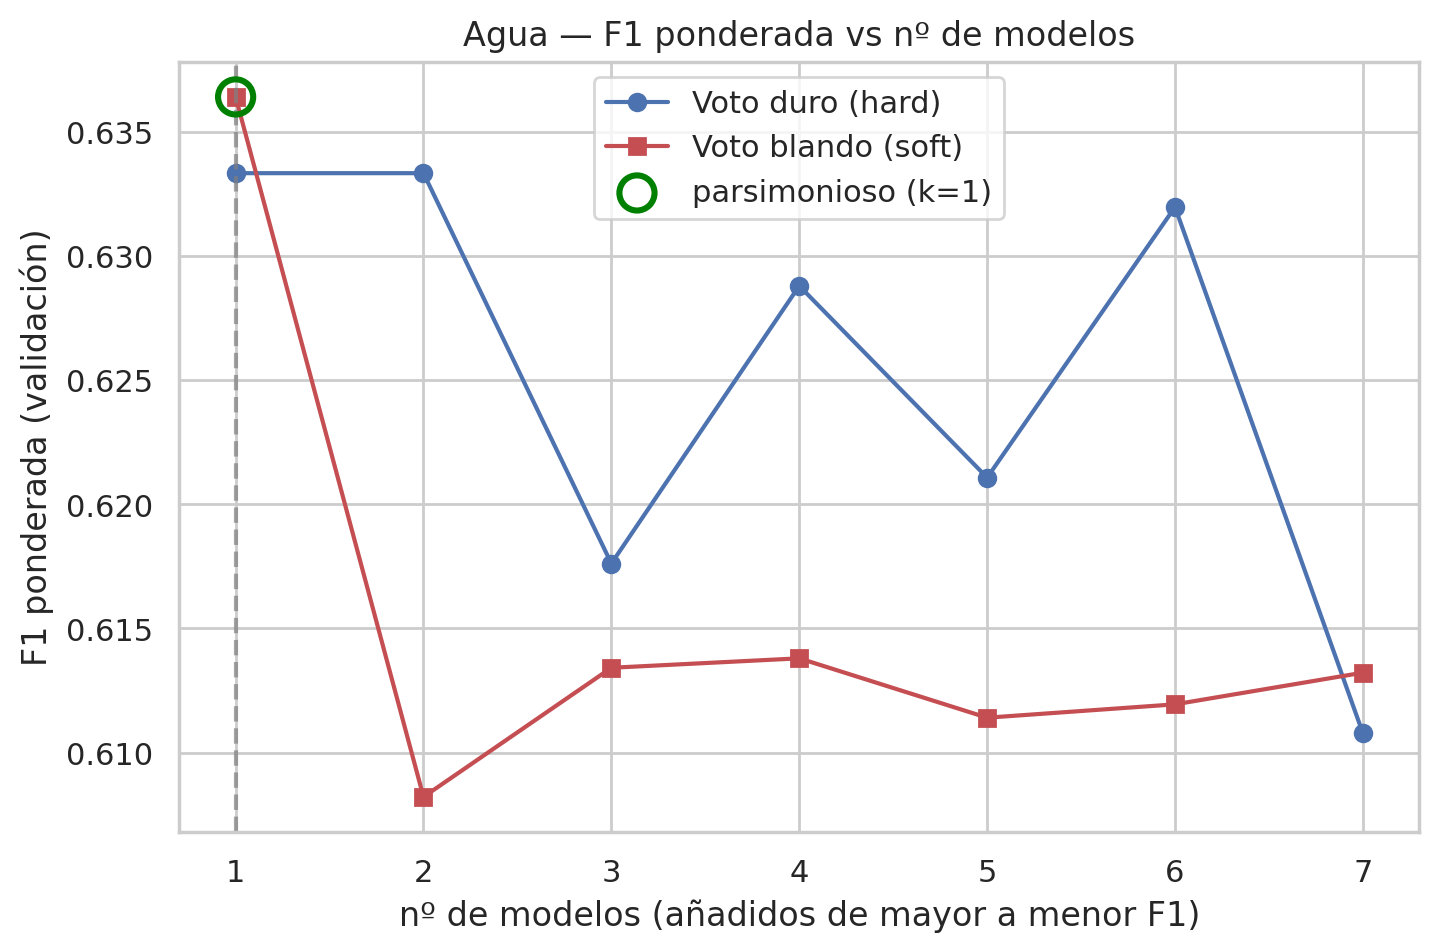

Orden por F1 ponderada individual:
  1. SVM RBF: 0.633
  2. Árbol: 0.608
  3. k-NN: 0.593
  4. Naïve Bayes: 0.574
  5. SVM lineal: 0.541
  6. Logística: 0.529
  7. Discriminante: 0.463

Conjunto parsimonioso: 1 modelo(s) -> ['SVM RBF']
F1 ponderada en k=1  ->  duro: 0.633 | blando: 0.636   (comité completo, blando: 0.613)


In [7]:
orden_w, k_w = voting_parsimonia(datos_w, 'Potability', balanceado=True,
                                 titulo='Agua — F1 ponderada vs nº de modelos')

Es un problema **difícil**. En la tabla (modelos por defecto) los **lineales colapsan** a la clase mayoritaria (F1 ≈ 0); al activar `class_weight='balanced'` en el comité dejan de hacerlo, pero siguen siendo flojos. La curva muestra que el **mejor modelo individual** (SVM RBF) ya alcanza el máximo y **añadir modelos no mejora** —incluso baja el voto blando—: el conjunto parsimonioso es de **un solo modelo**. Aquí combinar no aporta porque la mayoría de modelos base son débiles.



### <font color="steelblue">Capacidad del modelo ponderado (3 mejores)</font>

Estratificando por 'Potability'.
  Entrenamiento: 2293 muestras | Test: 983 muestras
Modelo ponderado (voto blando) con los 3 mejores: ['SVM RBF', 'Árbol', 'k-NN']

Métricas de clasificación en la muestra de entrenamiento
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1398
           1       1.00      0.96      0.98       895

    accuracy                           0.98      2293
   macro avg       0.99      0.98      0.98      2293
weighted avg       0.98      0.98      0.98      2293


 Métricas de clasificación en la muestra test
              precision    recall  f1-score   support

           0       0.67      0.76      0.71       600
           1       0.52      0.41      0.46       383

    accuracy                           0.62       983
   macro avg       0.60      0.59      0.59       983
weighted avg       0.61      0.62      0.61       983



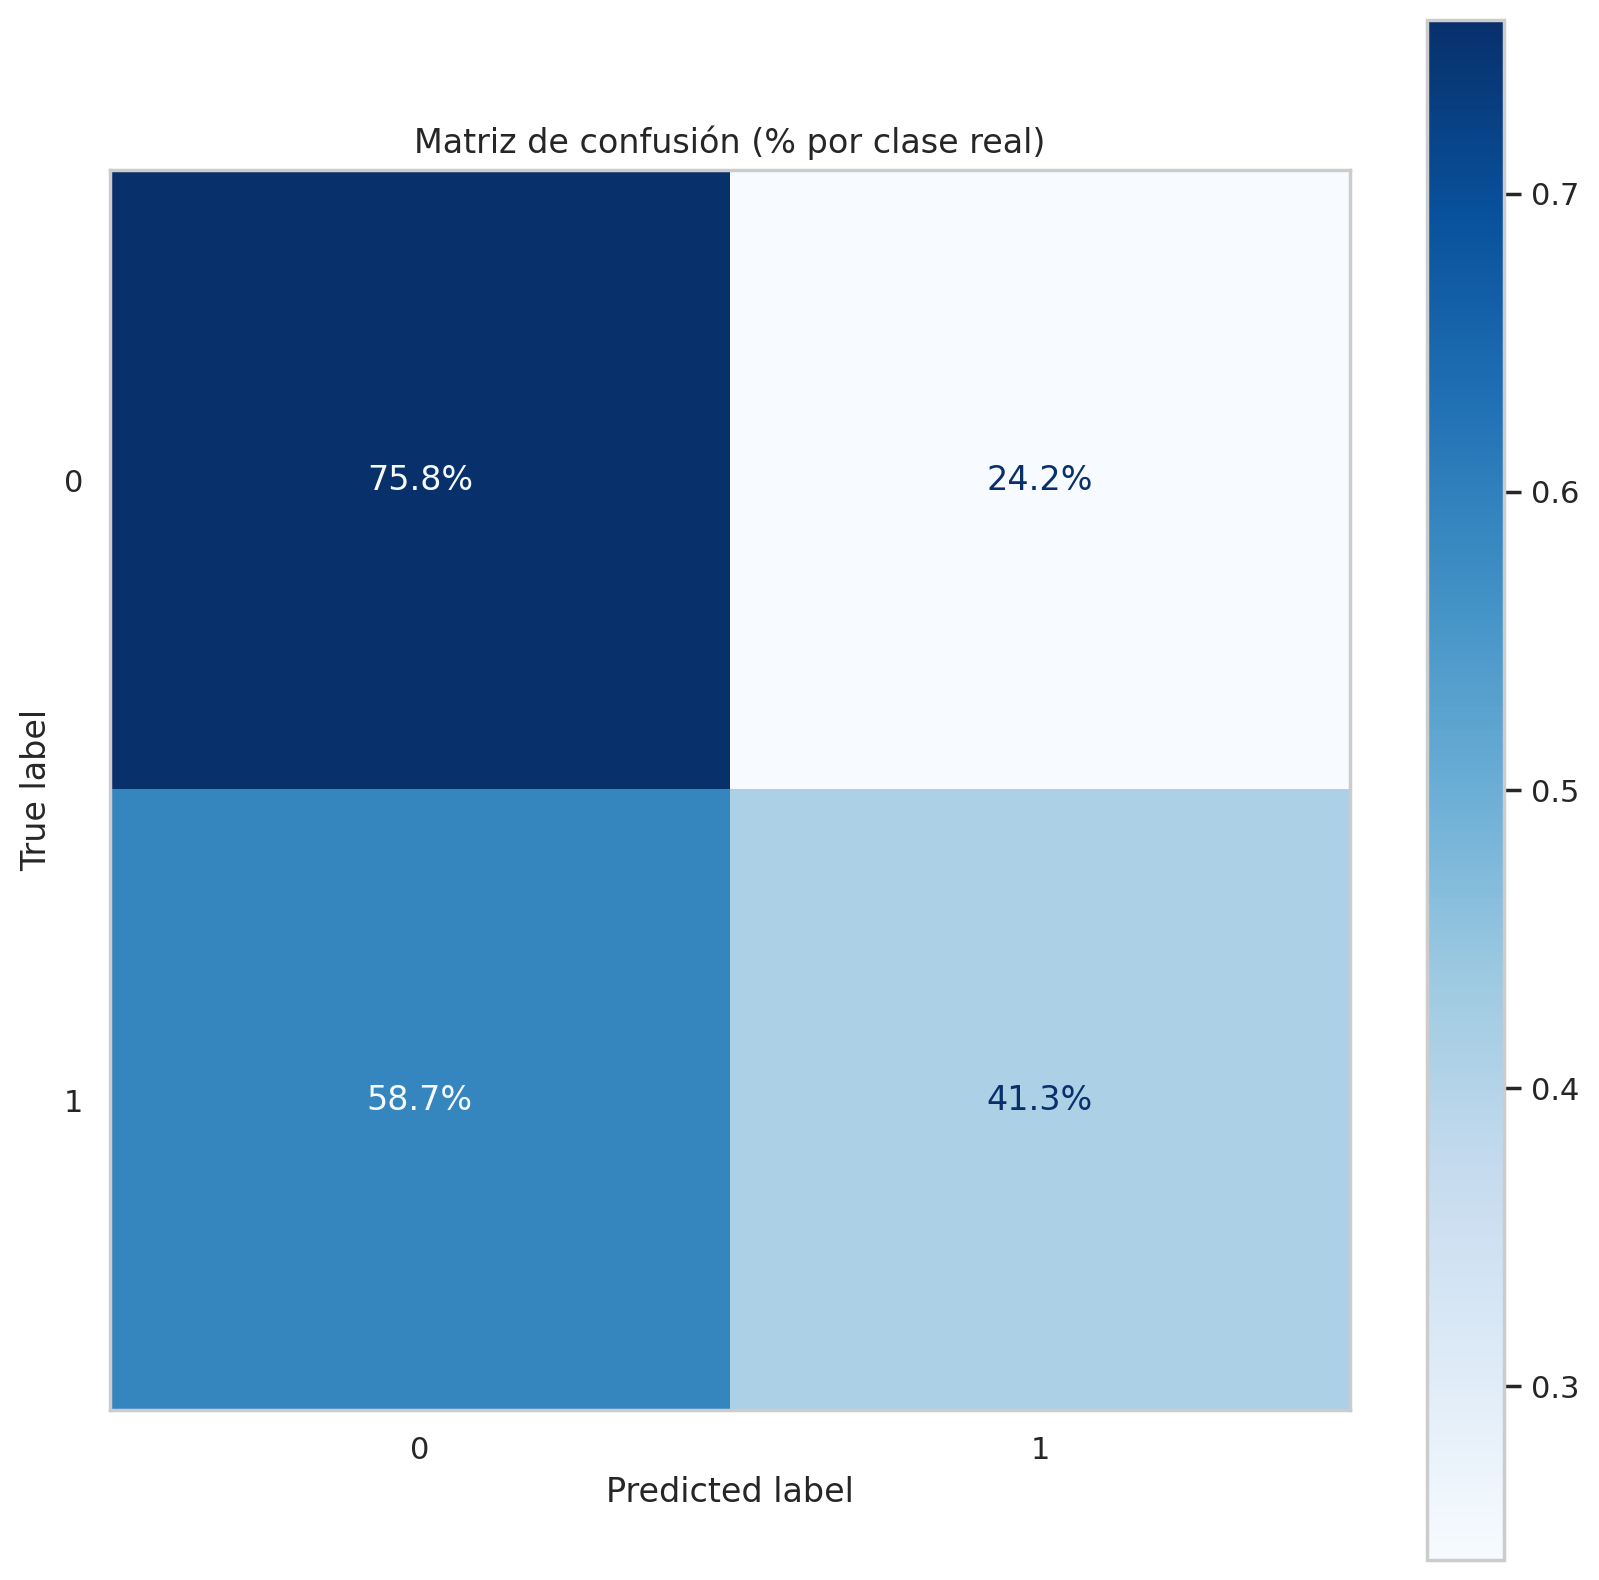

Validacion cruzada (10 folds, score=f1_weighted): media = 0.619 +/- 0.029


VotingClassifier(estimators=[('SVM RBF',
                              SVC(class_weight='balanced', probability=True,
                                  random_state=42)),
                             ('Árbol',
                              DecisionTreeClassifier(class_weight='balanced',
                                                     random_state=42)),
                             ('k-NN', KNeighborsClassifier())],
                 voting='soft')

In [8]:
evaluar_ponderado(datos_w, 'Potability', orden_w, balanceado=True)

El comité de los tres mejores (SVM RBF, árbol y k-NN) obtiene una F1 ponderada de **≈0.61** (test) y **0.615 ± 0.028** en validación cruzada: prácticamente igual que el mejor modelo individual. El comité **no mejora** porque solo el SVM RBF es competitivo y arrastra a dos modelos más flojos; la matriz de confusión refleja la dificultad del problema.

## <font color="steelblue">5.2. Cáncer de mama (binaria, desequilibrada)</font>

Clasificar tumores como **benignos (B)** o **malignos (M)** a partir de 30 características numéricas. También está algo **desequilibrado**, así que ponderamos.

In [9]:
url = 'https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/cancer.csv'
cancer = pd.read_csv(url).drop(columns='id')   # datos SIN limpiar: quitamos la columna identificador
cancer['diagnosis'] = cancer['diagnosis'].astype('category')
print('Dimensiones:', cancer.shape)
datos_c, _ = preprocesar_datos(cancer, 'diagnosis')   # estandariza las 30 variables numéricas
tabla_comparacion(datos_c, 'diagnosis', multiclase=False)

Dimensiones: (569, 31)
Estratificando por 'diagnosis'.
  Entrenamiento: 398 muestras | Test: 171 muestras
Clase positiva: 'M'
Entrenando lr...
Entrenando lda...
Entrenando nb...
Entrenando knn...
Entrenando svc...
Entrenando rbf...
Entrenando dt...
Entrenando bagging...


,Accuracy,Balanced_Accuracy,Recall,Specificity,F1,AUC
Algorithm,,,,,,
Discriminante,0.977,0.969,0.938,1.000,0.968,0.997
Logística,0.971,0.964,0.938,0.991,0.960,0.998
Bagging,0.971,0.961,0.922,1.000,0.959,0.986
k-NN,0.965,0.953,0.906,1.000,0.951,0.988
SVM RBF,0.965,0.953,0.906,1.000,0.951,0.997
SVM lineal,0.965,0.953,0.906,1.000,0.951,0.995
Naïve Bayes,0.936,0.923,0.875,0.972,0.911,0.993
Árbol,0.901,0.889,0.844,0.935,0.864,0.889


Estratificando por 'diagnosis'.
  Entrenamiento: 398 muestras | Test: 171 muestras


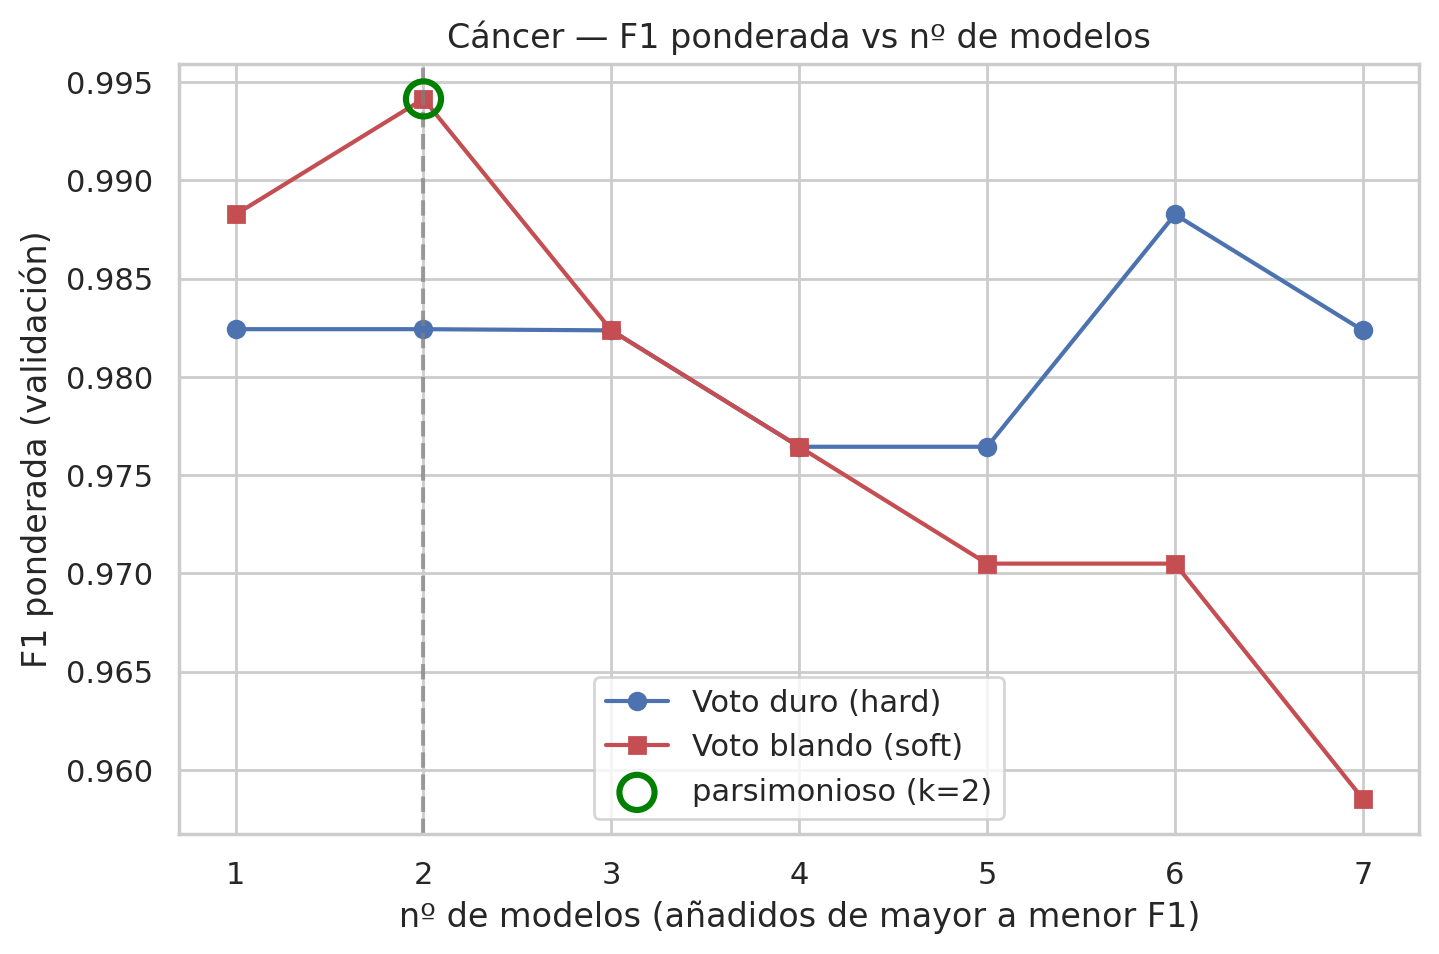

Orden por F1 ponderada individual:
  1. SVM RBF: 0.982
  2. Logística: 0.977
  3. Discriminante: 0.976
  4. SVM lineal: 0.965
  5. k-NN: 0.965
  6. Naïve Bayes: 0.935
  7. Árbol: 0.906

Conjunto parsimonioso: 2 modelo(s) -> ['SVM RBF', 'Logística']
F1 ponderada en k=2  ->  duro: 0.982 | blando: 0.994   (comité completo, blando: 0.959)


In [10]:
orden_c, k_c = voting_parsimonia(datos_c, 'diagnosis', balanceado=True,
                                 titulo='Cáncer — F1 ponderada vs nº de modelos')

Casi todos los modelos rinden muy bien. Ahora el voto **sí ayuda**: combinando los **dos mejores** modelos (SVM RBF y logística) el voto blando alcanza su **máximo** y supera tanto al mejor modelo individual como al comité completo de siete. Es el ejemplo perfecto de **parsimonia**: nos quedamos con **2 modelos**, más simples, rápidos y con mejor F1 ponderada que usarlos todos.



### <font color="steelblue">Capacidad del modelo ponderado (3 mejores)</font>

Estratificando por 'diagnosis'.
  Entrenamiento: 398 muestras | Test: 171 muestras
Modelo ponderado (voto blando) con los 3 mejores: ['SVM RBF', 'Logística', 'Discriminante']

Métricas de clasificación en la muestra de entrenamiento
              precision    recall  f1-score   support

           B       0.98      1.00      0.99       250
           M       1.00      0.96      0.98       148

    accuracy                           0.98       398
   macro avg       0.99      0.98      0.98       398
weighted avg       0.99      0.98      0.98       398


 Métricas de clasificación en la muestra test
              precision    recall  f1-score   support

           B       0.97      1.00      0.99       107
           M       1.00      0.95      0.98        64

    accuracy                           0.98       171
   macro avg       0.99      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



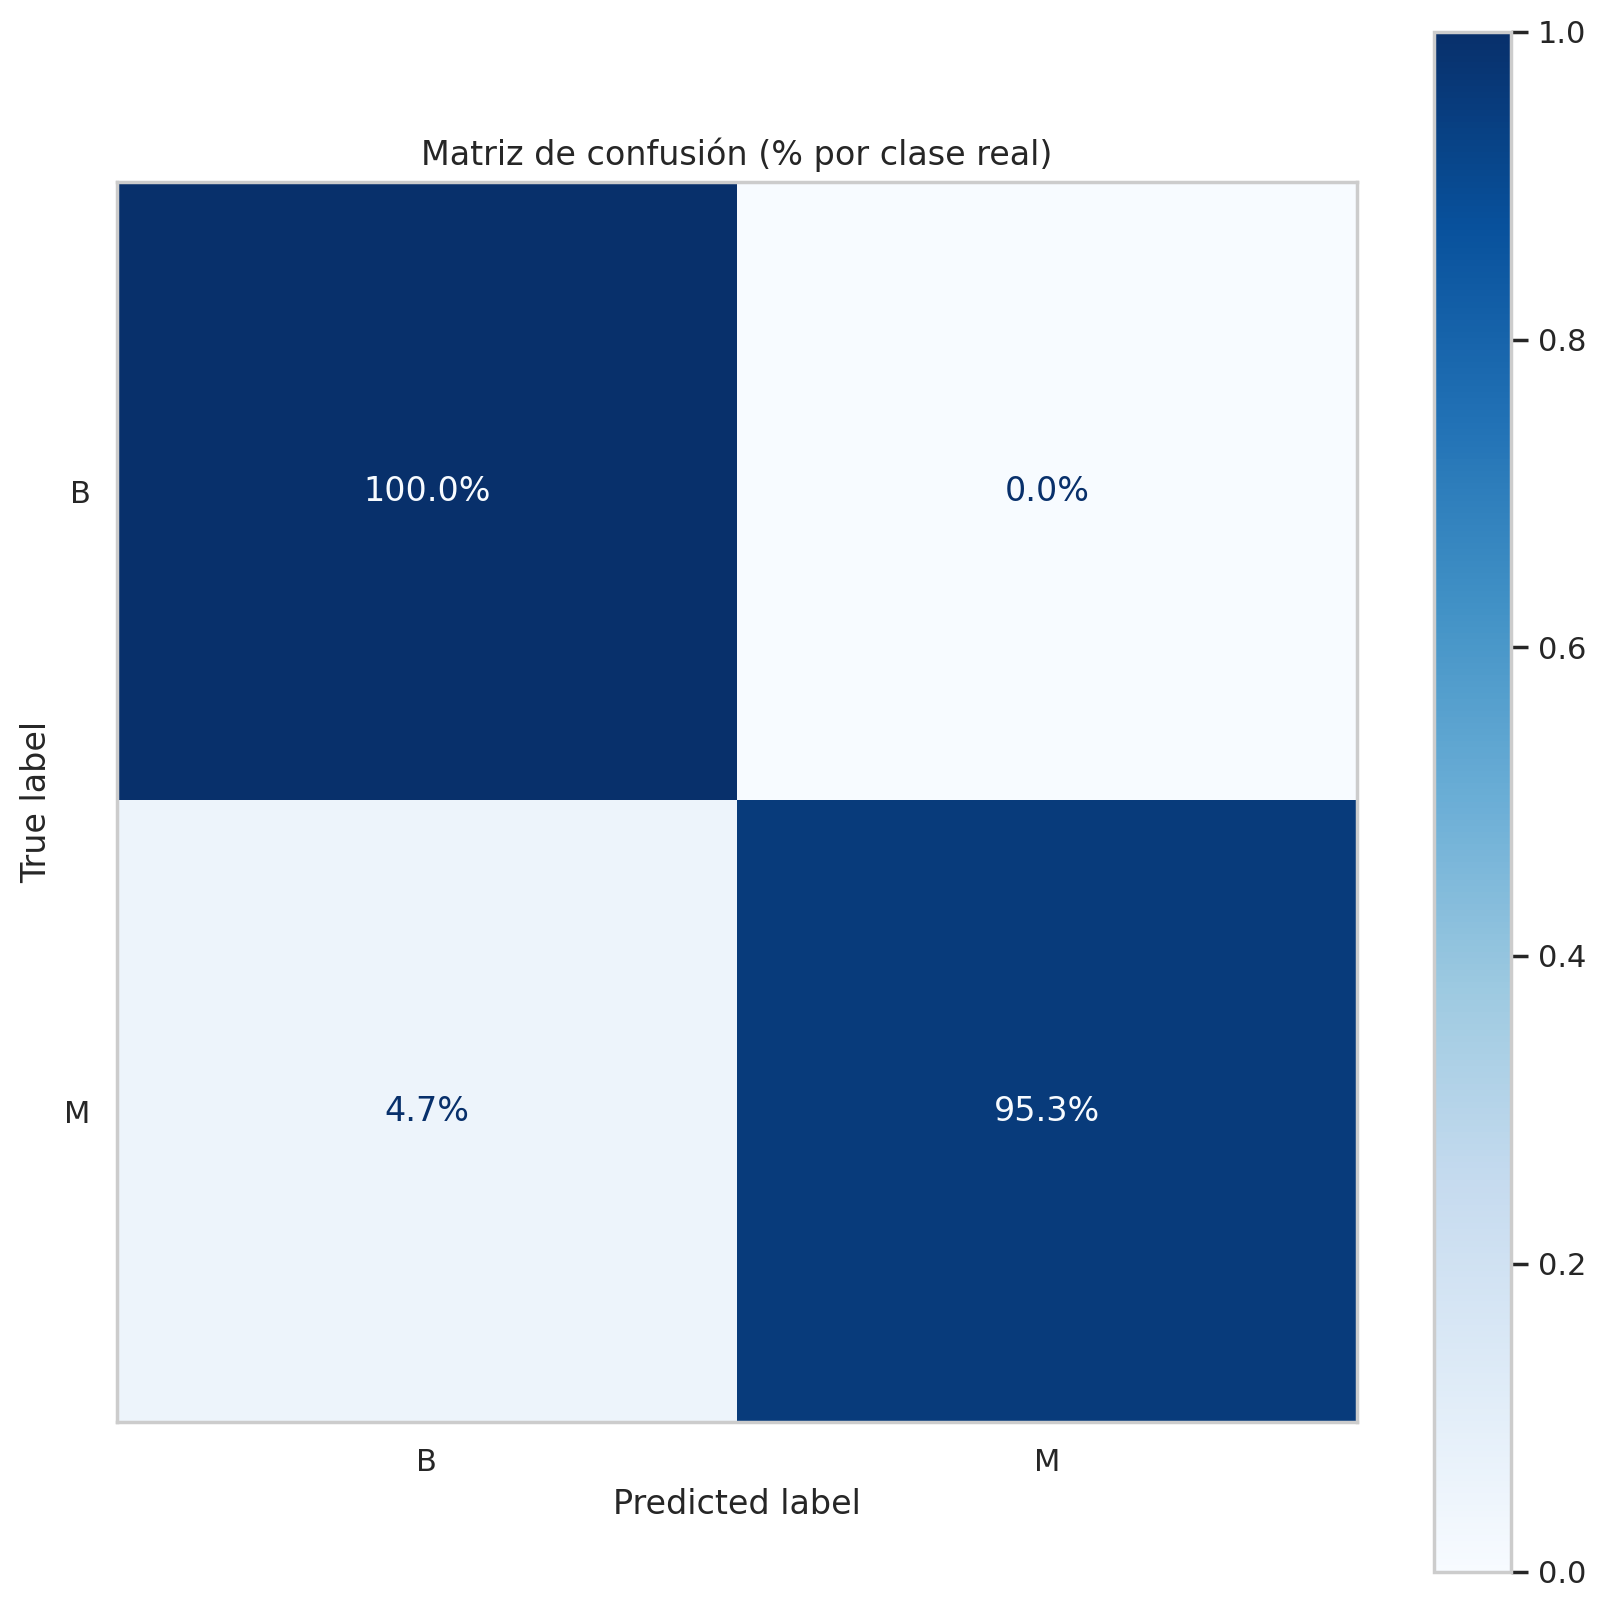

Validacion cruzada (10 folds, score=f1_weighted): media = 0.962 +/- 0.031


VotingClassifier(estimators=[('SVM RBF',
                              SVC(class_weight='balanced', probability=True,
                                  random_state=42)),
                             ('Logística',
                              LogisticRegression(class_weight='balanced',
                                                 max_iter=1000,
                                                 random_state=42)),
                             ('Discriminante', LinearDiscriminantAnalysis())],
                 voting='soft')

In [11]:
evaluar_ponderado(datos_c, 'diagnosis', orden_c, balanceado=True)

El modelo ponderado (SVM RBF, logística y discriminante) **rinde de forma excelente**: F1 ponderada **≈0.98** en test y **0.961 ± 0.032** en validación cruzada, con muy pocos errores en la matriz de confusión (y los pocos fallos están repartidos sin sacrificar la detección de malignos). Es una solución sólida y parsimoniosa.

## <font color="steelblue">5.3. Abulones (multiclase)</font>

Clasificar el **sexo** de abulones (M/F/I) a partir de medidas físicas. Las clases están bastante equilibradas; no activamos ponderación de clases.

Cargamos el fichero **sin limpiar** `abalone.csv`.

In [12]:
url = 'https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/abalone.csv'
abalone = pd.read_csv(url)                     # datos SIN limpiar
abalone['Sex'] = abalone['Sex'].astype('category')
print('Dimensiones:', abalone.shape)
datos_a, _ = preprocesar_datos(abalone, 'Sex')
tabla_comparacion(datos_a, 'Sex', multiclase=True)

Dimensiones: (4177, 9)
Estratificando por 'Sex'.
  Entrenamiento: 2923 muestras | Test: 1254 muestras
Entrenando lr...
Entrenando lda...
Entrenando nb...
Entrenando knn...
Entrenando svc...
Entrenando rbf...
Entrenando dt...
Entrenando bagging...


,Accuracy,Balanced_Accuracy,Recall,F1,AUC
Algorithm,,,,,
Logística,0.569,0.568,0.569,0.553,0.764
Discriminante,0.557,0.553,0.557,0.545,0.755
Bagging,0.541,0.545,0.541,0.538,0.723
k-NN,0.533,0.536,0.533,0.531,0.708
SVM RBF,0.546,0.535,0.546,0.500,0.756
Árbol,0.491,0.495,0.491,0.491,0.616
Naïve Bayes,0.506,0.524,0.506,0.467,0.730
SVM lineal,0.542,0.528,0.542,0.446,0.754


Estratificando por 'Sex'.
  Entrenamiento: 2923 muestras | Test: 1254 muestras


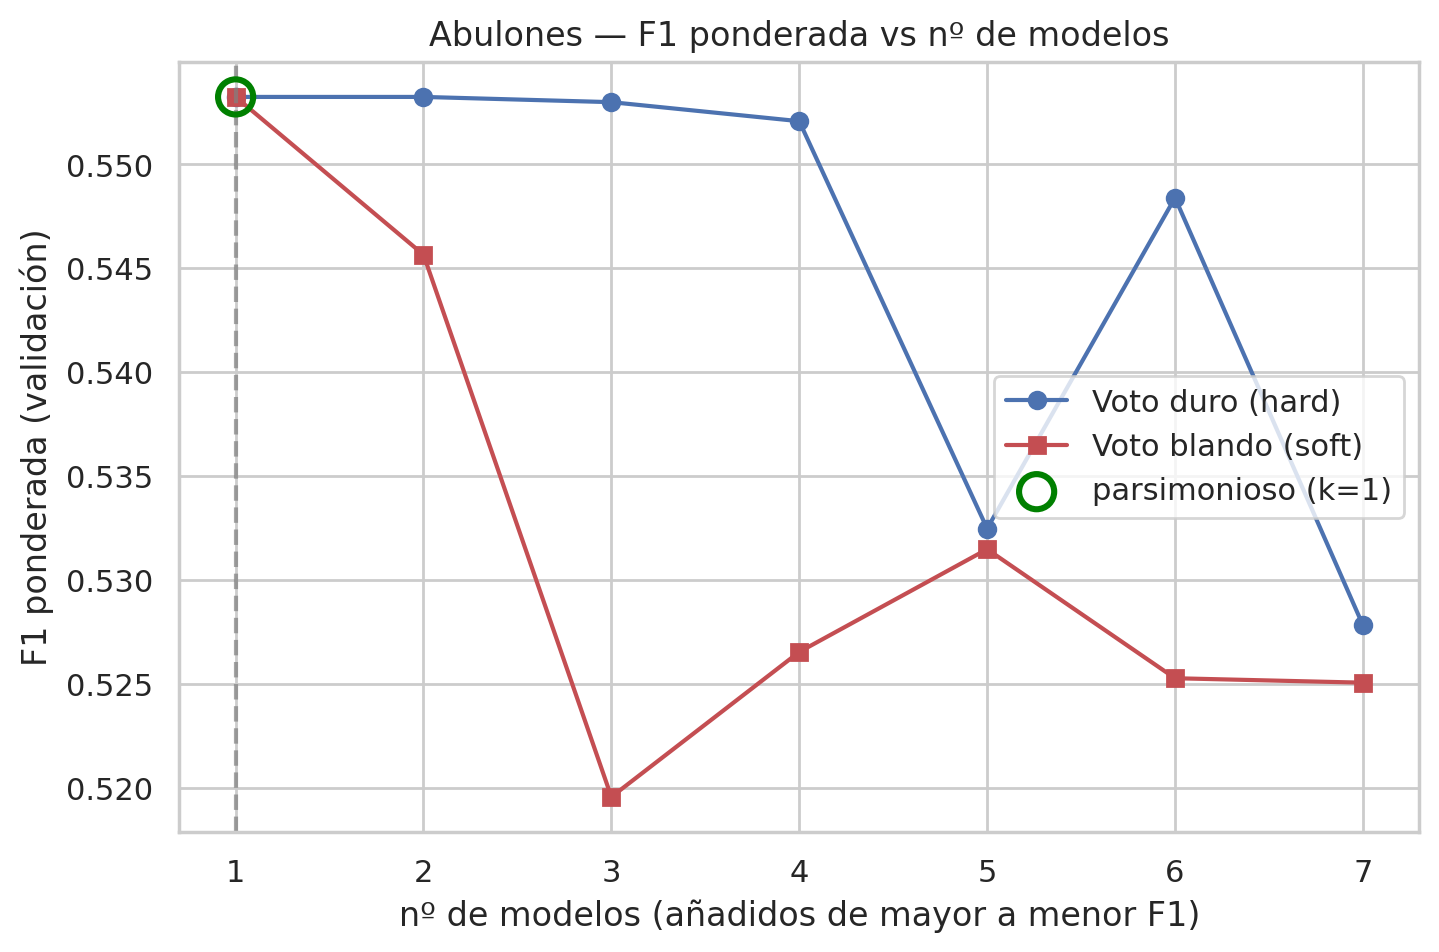

Orden por F1 ponderada individual:
  1. Logística: 0.553
  2. Discriminante: 0.545
  3. k-NN: 0.531
  4. SVM RBF: 0.500
  5. Árbol: 0.491
  6. Naïve Bayes: 0.467
  7. SVM lineal: 0.446

Conjunto parsimonioso: 1 modelo(s) -> ['Logística']
F1 ponderada en k=1  ->  duro: 0.553 | blando: 0.553   (comité completo, blando: 0.525)


In [13]:
orden_a, k_a = voting_parsimonia(datos_a, 'Sex', balanceado=False,
                                 titulo='Abulones — F1 ponderada vs nº de modelos')

Problema **intrínsecamente difícil**: todos los modelos rondan el 50 % porque machos y hembras se confunden. La curva es **plana y baja**, y añadir modelos no ayuda: el conjunto parsimonioso vuelve a ser de **un modelo**. El bagging **reduce varianza**, pero no compensa unas variables poco informativas.



### <font color="steelblue">Capacidad del modelo ponderado (3 mejores)</font>

Estratificando por 'Sex'.
  Entrenamiento: 2923 muestras | Test: 1254 muestras
Modelo ponderado (voto blando) con los 3 mejores: ['Logística', 'Discriminante', 'k-NN']

Métricas de clasificación en la muestra de entrenamiento
              precision    recall  f1-score   support

           F       0.66      0.50      0.57       915
           I       0.71      0.83      0.76       939
           M       0.61      0.65      0.63      1069

    accuracy                           0.66      2923
   macro avg       0.66      0.66      0.66      2923
weighted avg       0.66      0.66      0.66      2923


 Métricas de clasificación en la muestra test
              precision    recall  f1-score   support

           F       0.44      0.30      0.36       392
           I       0.66      0.78      0.72       403
           M       0.46      0.51      0.48       459

    accuracy                           0.53      1254
   macro avg       0.52      0.53      0.52      1254
weighted avg       0

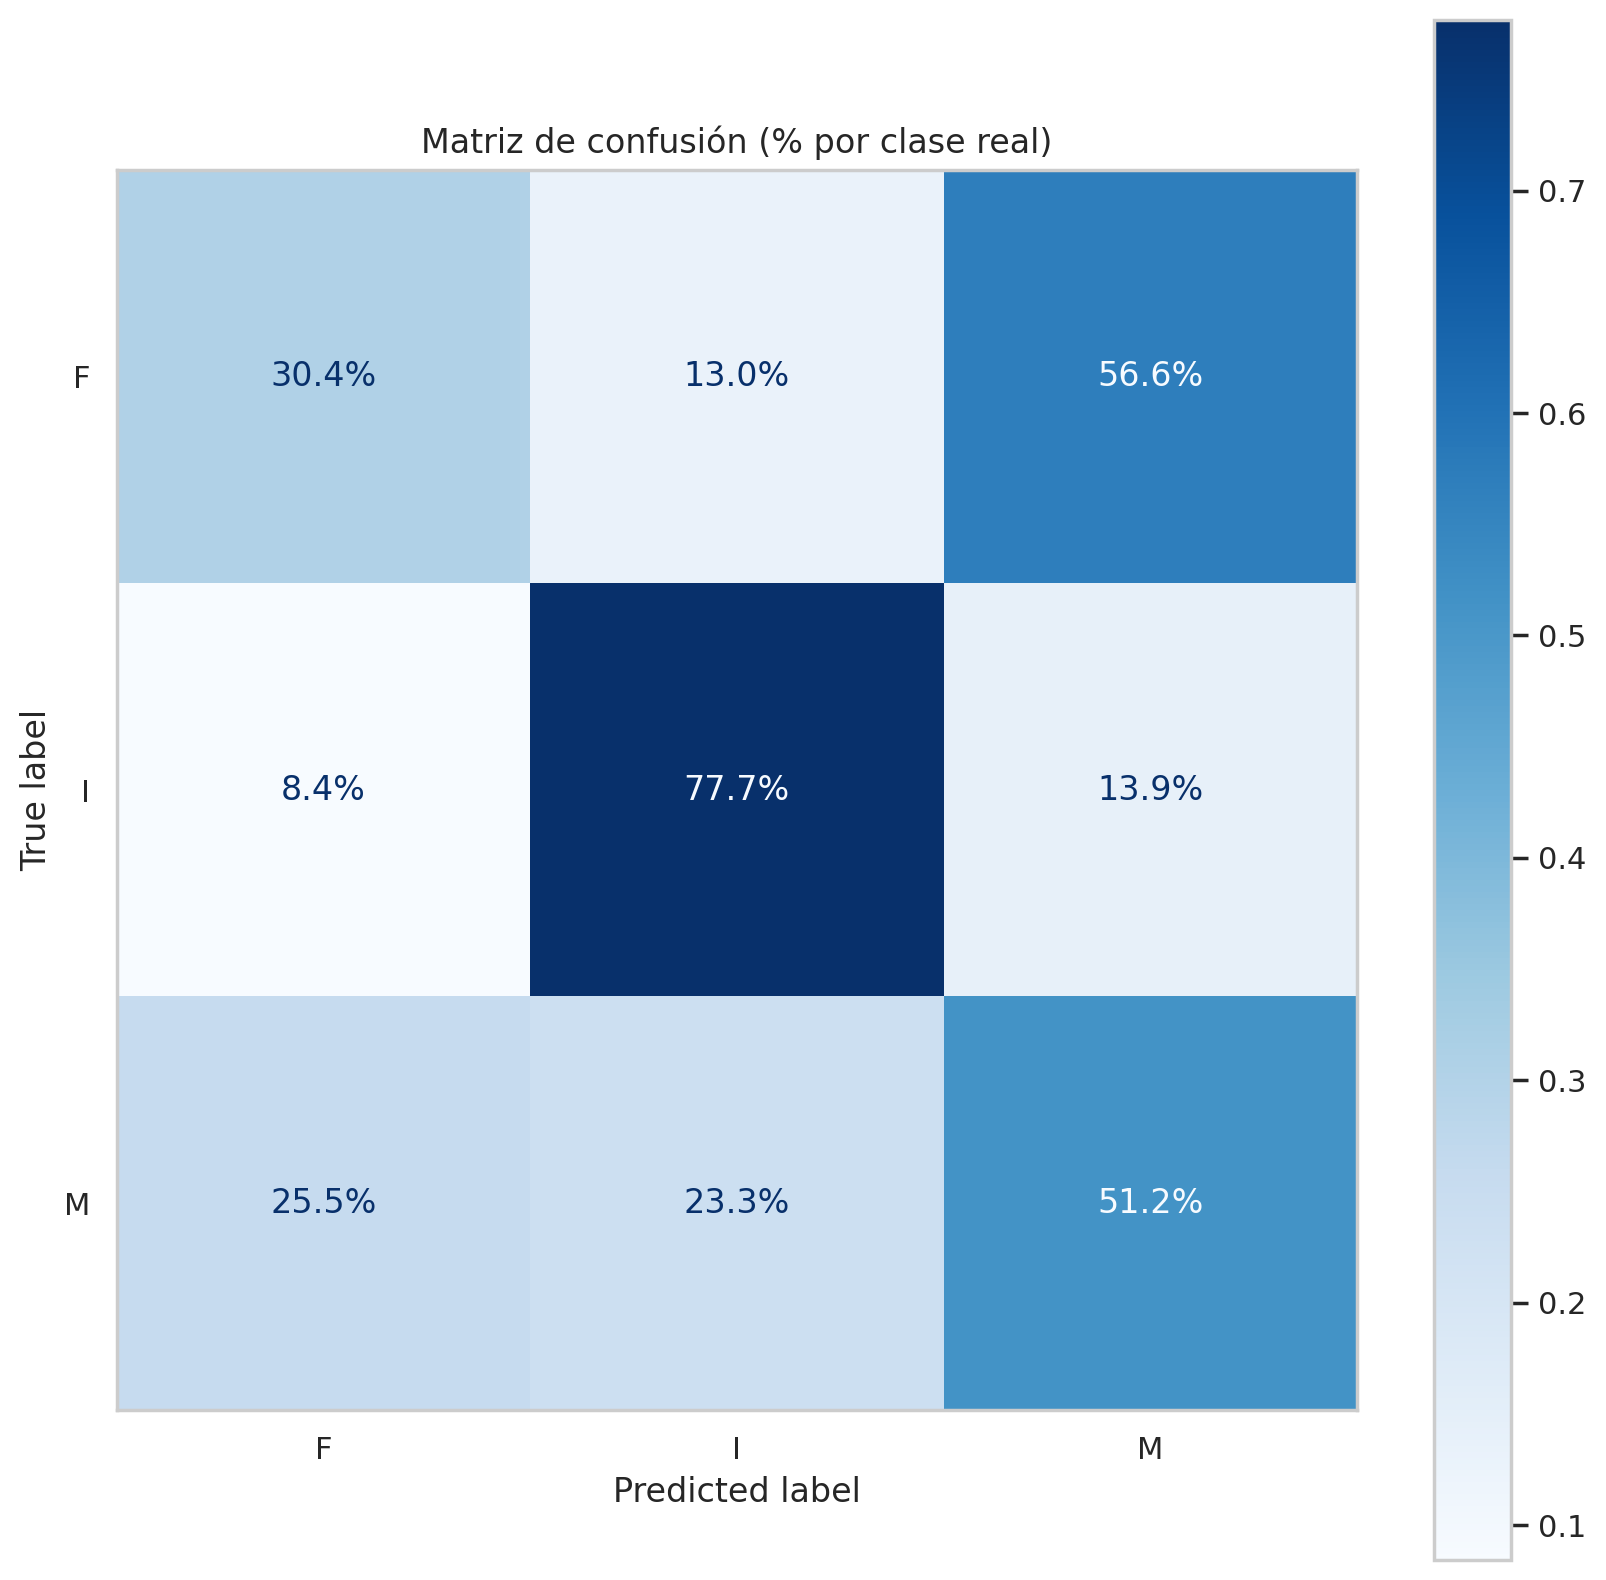

Validacion cruzada (10 folds, score=f1_weighted): media = 0.540 +/- 0.042


VotingClassifier(estimators=[('Logística',
                              LogisticRegression(max_iter=1000,
                                                 random_state=42)),
                             ('Discriminante', LinearDiscriminantAnalysis()),
                             ('k-NN', KNeighborsClassifier())],
                 voting='soft')

In [14]:
evaluar_ponderado(datos_a, 'Sex', orden_a, balanceado=False)

Incluso el comité de los tres mejores (logística, discriminante y k-NN) se queda en **≈0.52** (CV **0.529 ± 0.044**). La matriz de confusión confirma el problema: **M y F se confunden masivamente** y solo los infantiles (I) se distinguen. No es un problema de modelo, sino de **variables poco informativas**.

## <font color="steelblue">5.4. Clasificación de vinos</font>

In [15]:
vinos = load_wine()
wine = pd.DataFrame(vinos.data, columns=vinos.feature_names)
wine['cultivar'] = pd.Categorical(vinos.target)
datos_v, _ = preprocesar_datos(wine, 'cultivar')
tabla_comparacion(datos_v, 'cultivar', multiclase=True)

Estratificando por 'cultivar'.
  Entrenamiento: 124 muestras | Test: 54 muestras
Entrenando lr...
Entrenando lda...
Entrenando nb...
Entrenando knn...
Entrenando svc...
Entrenando rbf...
Entrenando dt...
Entrenando bagging...


,Accuracy,Balanced_Accuracy,Recall,F1,AUC
Algorithm,,,,,
Naïve Bayes,1.000,1.000,1.000,1.000,1.000
Logística,0.981,0.984,0.981,0.982,0.999
Discriminante,0.981,0.984,0.981,0.982,1.000
Bagging,0.981,0.984,0.981,0.982,0.999
SVM RBF,0.981,0.978,0.981,0.981,1.000
Árbol,0.963,0.959,0.963,0.963,0.970
SVM lineal,0.963,0.962,0.963,0.963,0.999
k-NN,0.944,0.952,0.944,0.945,0.995


Estratificando por 'cultivar'.
  Entrenamiento: 124 muestras | Test: 54 muestras


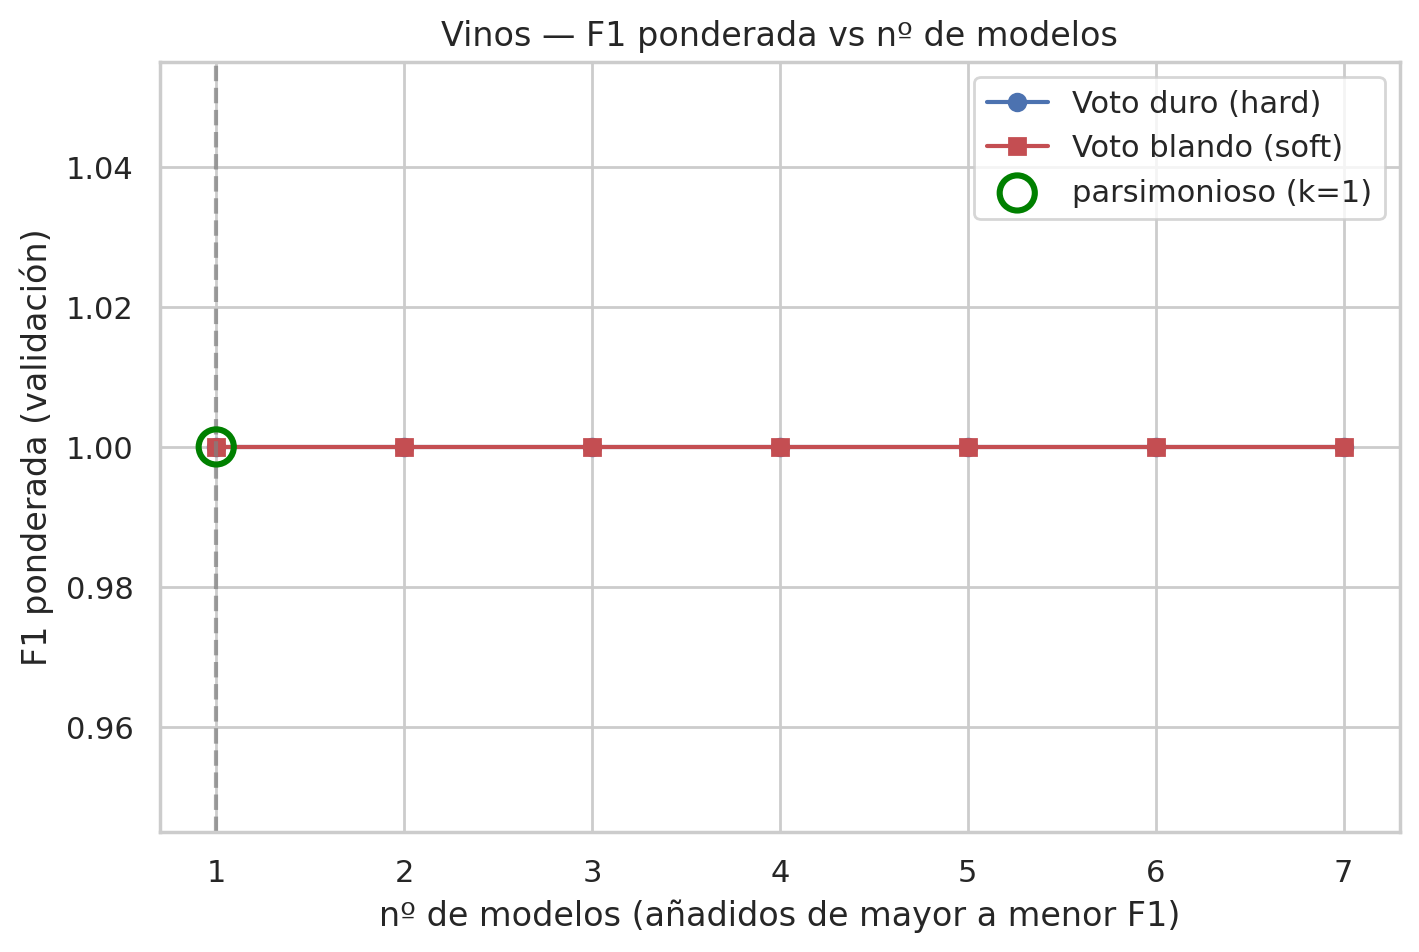

Orden por F1 ponderada individual:
  1. Naïve Bayes: 1.000
  2. Logística: 0.982
  3. Discriminante: 0.982
  4. SVM RBF: 0.981
  5. Árbol: 0.963
  6. SVM lineal: 0.963
  7. k-NN: 0.945

Conjunto parsimonioso: 1 modelo(s) -> ['Naïve Bayes']
F1 ponderada en k=1  ->  duro: 1.000 | blando: 1.000   (comité completo, blando: 1.000)


In [16]:
orden_v, k_v = voting_parsimonia(datos_v, 'cultivar', balanceado=False,
                                 titulo='Vinos — F1 ponderada vs nº de modelos')

Las clases están **muy bien separadas** y casi todos los modelos aciertan casi todo, alcanzando F1 ponderada ≈ 1. La curva está **al máximo desde el primer modelo**: con **uno** basta. Cuando el problema es fácil, el comité no tiene margen de mejora, aunque combinar añade **robustez** frente a variaciones de los datos.



## <font color="steelblue">Conclusión preliminar</font>

El patrón es claro y se repite: **más modelos no implica mejor F1**. El comité de voto **brilla cuando hay varios modelos buenos y algo distintos** (cáncer: 2 modelos baten a los 7), pero **no aporta** cuando hay un único modelo dominante (agua) o cuando ninguno separa bien las clases (abulones), y **no tiene margen** cuando el problema ya es fácil (vinos). De ahí la utilidad de la **curva de parsimonia**: nos quedamos con el **menor número de modelos** que sostiene la F1 ponderada. El voto **blando** suele igualar o superar al **duro** al aprovechar la confianza de cada modelo.


Una vez entrenados los modelos individuales resulta adecuado proceder con la optimización de dichos modelos si deseamos incluirlos en la ponderación de modelos.


# <font color="steelblue">6. Referencias</font>

* Breiman, L. (1996). *Bagging Predictors*. Machine Learning, 24(2).
* James, Witten, Hastie & Tibshirani (2021). *An Introduction to Statistical Learning* (cap. 8). Springer.
* Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow*. O'Reilly.
* scikit-learn — *Ensemble methods*: https://scikit-learn.org/stable/modules/ensemble.html